**Student1:** Hammani Abdeslem  

**Student2:** Fellah Mahdi

# Advanced Machine Learning — Lab 4
## Continual (Incremental) Learning: Catastrophic Forgetting, EWC, and Replay

> **Duration:** 2 hours | **Framework:** TensorFlow / Keras | **Dataset:** Split MNIST

---

###  Objectives
By the end of this lab you will be able to:
- Demonstrate **catastrophic forgetting** on a sequential benchmark
- Build a **Split MNIST** continual learning benchmark
- Implement and evaluate **Experience Replay**
- Implement and evaluate **EWC (Elastic Weight Consolidation)**
- Compare methods using **accuracy matrices** and **forgetting metrics**

---

###  Key formulas

**Accuracy matrix** — $A_{i,j}$ = accuracy on task $j$ right after training task $i$

**Forgetting** — $F_j = \max_{i \le K} A_{i,j} - A_{K,j}$

**EWC loss** — $\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta) + \dfrac{\lambda}{2}\sum_k F_k(\theta_k - \theta_k^{\text{old}})^2$


## Part 0 — Setup & Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)


2026-03-28 16:55:02.392929: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-28 16:55:02.407108: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 16:55:03.027107: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-28 16:55:06.689246: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

TensorFlow: 2.20.0


## Part 1 — Split MNIST Benchmark

We split MNIST into 5 sequential **binary** tasks:
| Task | Digits |
|------|--------|
| T1   | 0 vs 1 |
| T2   | 2 vs 3 |
| T3   | 4 vs 5 |
| T4   | 6 vs 7 |
| T5   | 8 vs 9 |


In [2]:
# Load and preprocess MNIST
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train_full = (x_train_full.astype('float32') / 255.0).reshape(-1, 784)
x_test_full  = (x_test_full.astype('float32')  / 255.0).reshape(-1, 784)

TASKS = [(0,1),(2,3),(4,5),(6,7),(8,9)]

def make_task(a, b):
    """Return binary task (a vs b) as (train, test) tuples."""
    def extract(X, y):
        idx = np.where((y == a) | (y == b))[0]
        Xs = X[idx]
        ys = (y[idx] == b).astype(np.int32)
        p = np.random.permutation(len(ys))
        return Xs[p], ys[p]
    return extract(x_train_full, y_train_full), extract(x_test_full, y_test_full)

tasks_data = [make_task(a,b) for a,b in TASKS]
print(f'Built {len(tasks_data)} tasks')
for i,(t,v) in enumerate(tasks_data):
    print(f'  T{i+1} ({TASKS[i][0]} vs {TASKS[i][1]}): train={t[0].shape[0]}, test={v[0].shape[0]}')


Built 5 tasks
  T1 (0 vs 1): train=12665, test=2115
  T2 (2 vs 3): train=12089, test=2042
  T3 (4 vs 5): train=11263, test=1874
  T4 (6 vs 7): train=12183, test=1986
  T5 (8 vs 9): train=11800, test=1983


###  Exercise 1 — Conceptual Questions

In [ ]:
# Q1: When training on T2, SGD updates the shared weights.
#     Why does this harm performance on T1?
#
# YOUR ANSWER: When training on T2, standard SGD optimizes the shared parameters 
# solely to minimize the loss for T2's data distribution. Because T1 data is entirely 
# absent from the current batches, there is no gradient signal to constrain or preserve 
# the weights, causing the network to greedily overwrite the specific internal 
# representations previously learned for T1.
#
# Q2: Forgetting is especially strong when tasks share few features.
#     Explain why this is the case for digit pairs (0/1) vs (8/9).
#
# YOUR ANSWER: Digits 0 and 1 rely on simple geometric features (vertical lines, 
# simple loops), whereas 8 and 9 consist of complex, intersecting curves. Because 
# these input feature spaces are largely disjoint, learning to classify 8 and 9 
# requires a drastic restructuring of the network's feature extraction layers. This 
# massive displacement in the parameter space completely destroys the simpler, 
# non-overlapping filters previously optimized for 0 and 1.

## Part 2 — Shared MLP Model

All methods share the same 784 → 256 → 256 → 1 (sigmoid) architecture.


In [3]:
def build_mlp():
    return keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1,   activation='sigmoid'),
    ])

loss_fn = keras.losses.BinaryCrossentropy()

def eval_all_tasks(model):
    """Return accuracy on every task's test set."""
    return np.array([
        model.evaluate(Xte, yte, verbose=0)[1]
        for (_, _),(Xte, yte) in tasks_data
    ])


## Part 3 — Baseline: Sequential Fine-tuning (shows forgetting)

Train the model on T1 → T2 → … → T5 with no protection.
After each task, evaluate on **all** tasks and record into accuracy matrix $A$.


In [4]:
def run_finetune(epochs=2):
    model = build_mlp()
    opt = keras.optimizers.Adam(1e-3)
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])

    A_rows = []
    for i, ((Xtr, ytr),(Xte, yte)) in enumerate(tasks_data):
        model.fit(Xtr, ytr, epochs=epochs, batch_size=128, verbose=0)
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

baseline_model, A_base = run_finetune(epochs=2)


2026-03-28 16:58:38.932406: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


After T1: [0.999 0.46  0.566 0.619 0.381]
After T2: [0.768 0.992 0.685 0.853 0.5  ]
After T3: [0.211 0.781 0.999 0.338 0.142]
After T4: [0.843 0.805 0.466 0.998 0.639]
After T5: [0.358 0.59  0.101 0.83  0.987]


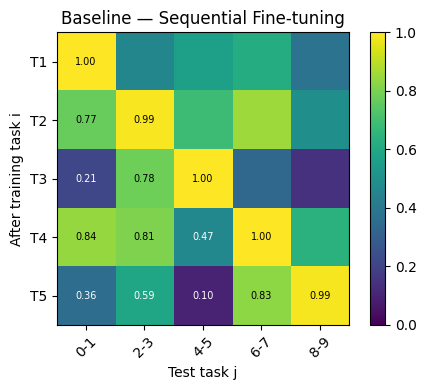

In [5]:
def plot_acc_matrix(A, title):
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Test task j')
    ax.set_ylabel('After training task i')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels([f'{a}-{b}' for a,b in TASKS], rotation=45)
    ax.set_yticklabels([f'T{i+1}' for i in range(5)])
    for ii in range(5):
        for jj in range(5):
            if ii >= jj:
                ax.text(jj, ii, f'{A[ii,jj]:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if A[ii,jj]<0.6 else 'black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()

plot_acc_matrix(A_base, 'Baseline — Sequential Fine-tuning')


###  Exercise 2 — Forgetting Metric

In [6]:
# Q1: Which cell in A_base shows Task 1 accuracy after training all 5 tasks?
# (row index?, column index?) — answer in comment
# A: row=4, col=0

# Q2: Compute forgetting vector F and average forgetting F_bar
def forgetting(A):
    # F_j = max_i A[i,j] - A[-1,j]  for j in range(K)
    K = A.shape[1]  # Get the total number of tasks (number of columns)
    F = np.zeros(K) # Create an empty array to store the forgetting score for each task
    
    for j in range(K):
        # Find the absolute highest accuracy the model EVER achieved on task j
        best_accuracy = np.max(A[:, j])
        
        # Find the final accuracy the model has on task j at the very end (last row)
        final_accuracy = A[-1, j]
        
        # The forgetting score is the difference between its best performance and its final performance
        F[j] = best_accuracy - final_accuracy
        
    return F

# Provided execution code
F_base = forgetting(A_base)
print('Forgetting per task:', F_base)
print('Average forgetting: ', np.mean(F_base))

Forgetting per task: [0.64066193 0.40205681 0.89807899 0.16767371 0.        ]
Average forgetting:  0.42169428765773775


## Part 4 — Method 1: Experience Replay

**Strategy:** keep a memory buffer of past samples. While training on task $i$,
mix current data with replay samples from memory.

### 4.1 — Implement MemoryBuffer


In [7]:
class MemoryBuffer:
    """Circular FIFO buffer storing (X, y) pairs."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.X = np.empty((0, 784), dtype=np.float32)
        self.y = np.empty((0,),    dtype=np.int32)

    def add(self, X, y):
        """Add samples; drop oldest if over capacity."""
        # TODO
        # Hint: concatenate, then keep only last `capacity` rows
        # 1. Glue the new data to the end of our existing data
        self.X = np.concatenate([self.X, X], axis=0)
        self.y = np.concatenate([self.y, y], axis=0)
        
        # 2. If we exceed the maximum capacity, keep only the newest samples
        if len(self.y) > self.capacity:
            # Slicing with [-capacity:] grabs exactly the last 'capacity' elements
            self.X = self.X[-self.capacity:]
            self.y = self.y[-self.capacity:]
        

    def sample(self, batch_size):
        """Return a random batch from the buffer (or None if empty)."""
        # 1. Check if the buffer is empty
        if len(self.y) == 0:
            return None
        
        # 2. Make sure we don't ask for more samples than we currently have
        actual_size = min(batch_size, len(self.y))
        
        # 3. Randomly pick 'actual_size' indices without replacing them
        indices = np.random.choice(len(self.y), size=actual_size, replace=False)
        
        # 4. Return the chosen samples
        return self.X[indices], self.y[indices]

    def __len__(self):
        return len(self.y)

# Quick test (should print: 100, then 100 because capacity=100)
buf = MemoryBuffer(capacity=100)
buf.add(np.zeros((80, 784), dtype=np.float32), np.zeros(80, dtype=np.int32))
buf.add(np.zeros((50, 784), dtype=np.float32), np.ones(50, dtype=np.int32))
print('Buffer size (expect 100):', len(buf))


Buffer size (expect 100): 100


### 4.2 — Training Loop with Replay

In [8]:
def run_replay(mem_capacity=2000, replay_batch=64, samples_per_task=400, epochs=2):
    model = build_mlp()
    # We compile the model just to have standard metrics, but we will 
    # write a custom training loop below using tf.GradientTape
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    opt   = keras.optimizers.Adam(1e-3)
    buf   = MemoryBuffer(capacity=mem_capacity)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):

        # ---- Training ----
        ds = (tf.data.Dataset
                .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
                .shuffle(10_000, seed=SEED)
                .batch(128))

        for _ in range(epochs):
            for xb, yb in ds:
                # 1. Try to get old data from the memory buffer
                replay = buf.sample(replay_batch)
                
                # 2. If we have old data, mix it with the new data
                if replay is not None:
                    xm, ym = replay
                    xb = tf.concat([xb, tf.cast(xm, tf.float32)], axis=0)
                    yb = tf.concat([tf.reshape(yb,(-1,1)),
                                    tf.reshape(tf.cast(ym, tf.float32),(-1,1))], axis=0)
                else:
                    yb = tf.reshape(yb, (-1,1))

                # ---- Compute loss and apply gradient ----
                # 3. Use GradientTape to "record" the network's operations
                with tf.GradientTape() as tape:
                    # Make predictions on the mixed batch (old + new data)
                    preds = model(xb, training=True)
                    # Calculate how wrong the predictions are
                    loss = tf.reduce_mean(keras.losses.binary_crossentropy(yb, preds))
                
                # 4. Calculate the gradients (how to adjust the weights to fix the error)
                grads = tape.gradient(loss, model.trainable_variables)
                
                # 5. Apply the adjustments to the network
                opt.apply_gradients(zip(grads, model.trainable_variables))

        # ---- Add current task samples to buffer ----
        # 6. Task is finished! Now we randomly pick some examples from this task to save for the future.
        num_samples = min(samples_per_task, len(Xtr))
        indices = np.random.choice(len(Xtr), size=num_samples, replace=False)
        buf.add(Xtr[indices], ytr[indices])

        # Evaluate and record
        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

# Uncomment to run!
replay_model, A_replay = run_replay()

2026-03-28 18:14:44.181117: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-28 18:14:50.717926: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T1: [1.    0.477 0.546 0.651 0.387]


2026-03-28 18:15:05.644607: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T2: [0.994 0.991 0.69  0.792 0.543]
After T3: [0.983 0.983 0.997 0.46  0.188]


2026-03-28 18:15:33.838861: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T4: [0.979 0.957 0.959 0.997 0.574]
After T5: [0.949 0.961 0.901 0.981 0.984]


## Part 5 — Method 2: EWC (Elastic Weight Consolidation)

EWC adds a regularisation term that penalises changes to important weights.

$$\mathcal{L}(\theta) = \mathcal{L}_{\text{new}}(\theta)
+ \frac{\lambda}{2}\sum_k F_k(\theta_k - \theta_k^{\text{old}})^2$$

### 5.1 — Diagonal Fisher Estimation


In [9]:
def fisher_diagonal(model, X, y, n_samples=1000):
    """
    Estimate diagonal Fisher information.
    F_k ≈ (1/N) Σ (∂ log p(y|x;θ) / ∂θ_k)^2
    """
    n = min(n_samples, len(X))
    idx = np.random.choice(len(X), size=n, replace=False)
    Xs = tf.constant(X[idx], dtype=tf.float32)
    ys = tf.constant(y[idx].reshape(-1,1), dtype=tf.float32)

    # Accumulator (one tensor per variable, same shape)
    F = [tf.zeros_like(v) for v in model.trainable_variables]

    for i in range(n):
        xi = Xs[i:i+1]
        yi = ys[i:i+1]
        
        with tf.GradientTape() as tape:
            # 1. Forward pass to get the model's prediction
            pred = model(xi, training=False)
            
            # 2. Compute the log-likelihood (negative of the loss)
            import keras
            log_lik = -keras.losses.binary_crossentropy(yi, pred)
            
        # 3. Calculate gradients of the log-likelihood with respect to the weights
        grads = tape.gradient(log_lik, model.trainable_variables)
        
        # 4. Square the gradients and add them to our running total (Accumulator)
        F = [f + tf.square(g) for f, g in zip(F, grads)]

    # 5. Divide by 'n' to get the average
    return [f / tf.cast(n, tf.float32) for f in F]

### 5.2 — EWCTrainer class

In [13]:
class EWCTrainer:
    def __init__(self, model, lam=100.0):
        self.model     = model
        self.lam       = lam
        self.theta_old = None   # list of tf.Tensor (frozen copy of weights)
        self.F         = None   # list of tf.Tensor (Fisher diagonal)
        self.opt       = keras.optimizers.Adam(1e-3)

    # ------------------------------------------------------------------
    def ewc_penalty(self):
        """Return scalar EWC regularisation term."""
        # If this is the very first task, there are no old memories to protect!
        if self.theta_old is None:
            return tf.constant(0.0)
        
        penalty = tf.constant(0.0)
        for v, v_old, f in zip(self.model.trainable_variables,
                                self.theta_old, self.F):
            # Accumulate: F * (v - v_old)^2
            # This mathematically calculates the "tension" on the rubber bands
            penalty += tf.reduce_sum(f * tf.square(v - v_old))
            
        # Multiply by lambda / 2 as per the EWC equation
        return 0.5 * self.lam * penalty

    # ------------------------------------------------------------------
    def train_task(self, Xtr, ytr, epochs=2, batch_size=128):
        """Custom training loop with EWC penalty."""
        ds = (tf.data.Dataset
                .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
                .shuffle(10_000) 
                .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb,(-1,1)), tf.float32)
                
                with tf.GradientTape() as tape:
                    pred = self.model(xb, training=True)
                    
                    # 1. How well are we doing on the CURRENT task?
                    task_loss = tf.reduce_mean(keras.losses.binary_crossentropy(yb, pred))
                    
                    # 2. Total Loss = Current Task Error + Penalty for breaking old memories
                    loss = task_loss + self.ewc_penalty()
                    
                # Calculate how to adjust the weights to minimize the TOTAL loss
                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(
                    zip(grads, self.model.trainable_variables))

    # ------------------------------------------------------------------
    def consolidate(self, X, y):
        """Save θ_old and compute Fisher after finishing a task."""
        # 1. Take a snapshot! Save a frozen copy of the weights that just solved this task
        # We use tf.identity so it makes a true copy, not just a reference.
        self.theta_old = [tf.identity(v) for v in self.model.trainable_variables]
        
        # 2. Calculate the "importance scores" for these frozen weights using 
        # the fisher_diagonal function we built in the previous step.
        self.F = fisher_diagonal(self.model, X, y)

### 5.3 — Run EWC

In [14]:
def run_ewc(lam=100.0, epochs=2):
    model   = build_mlp()
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    trainer = EWCTrainer(model, lam=lam)

    A_rows = []
    for i, ((Xtr, ytr), _) in enumerate(tasks_data):
        trainer.train_task(Xtr, ytr, epochs=epochs)
        trainer.consolidate(Xtr, ytr)

        accs = eval_all_tasks(model)
        A_rows.append(accs)
        print(f'After T{i+1}: {np.round(accs,3)}')

    return model, np.vstack(A_rows)

ewc_model, A_ewc = run_ewc(lam=100.0)   # uncomment after implementing


After T1: [0.998 0.402 0.531 0.583 0.442]
After T2: [0.738 0.987 0.703 0.789 0.541]


2026-03-29 03:28:51.443315: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T3: [0.126 0.813 0.998 0.392 0.142]
After T4: [0.772 0.838 0.52  0.996 0.637]
After T5: [0.365 0.611 0.101 0.846 0.987]


### Exercise 3 — EWC Hyperparameter Analysis

In [15]:
# Q1: What happens when λ is very small (e.g. 0.01)?
#     What about very large (e.g. 100000)?
# YOUR ANSWER: When λ is very small, the EWC regularization penalty becomes 
# negligible, reducing the optimization to standard fine-tuning which results 
# in severe catastrophic forgetting. Conversely, when λ is extremely large, 
# the penalty dominates the loss function and rigidly locks the weights in 
# place. This causes "intransigence," meaning the network perfectly retains 
# old knowledge but completely fails to learn the new task.

# Q2: Why might EWC fail when tasks require very different feature representations?
# YOUR ANSWER: EWC mathematically assumes that a satisfactory joint solution 
# for both tasks exists within the immediate local neighborhood of the old 
# parameters (relying on a second-order Taylor approximation). When new tasks 
# require fundamentally different features, the network must make massive jumps 
# in the parameter space to learn them. EWC's penalty restricts these necessary 
# large updates, trapping the network in a suboptimal local minimum and 
# preventing it from adapting to the new data distribution.

## Part 6 — Compare All Methods

Run all three methods, compute forgetting, and compare.


After T1: [0.999 0.425 0.544 0.607 0.413]
After T2: [0.78  0.992 0.7   0.856 0.5  ]
After T3: [0.145 0.794 0.998 0.371 0.135]
After T4: [0.809 0.816 0.478 0.998 0.626]
After T5: [0.362 0.594 0.106 0.84  0.988]
After T1: [1.    0.498 0.586 0.629 0.354]
After T2: [0.994 0.989 0.678 0.798 0.546]
After T3: [0.986 0.981 0.996 0.492 0.196]
After T4: [0.977 0.964 0.962 0.995 0.617]
After T5: [0.97  0.955 0.893 0.978 0.989]


2026-03-29 03:36:28.724862: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T1: [0.999 0.476 0.551 0.666 0.378]
After T2: [0.767 0.994 0.663 0.821 0.537]
After T3: [0.113 0.85  0.998 0.348 0.19 ]
After T4: [0.79  0.845 0.552 0.996 0.629]
After T5: [0.218 0.631 0.115 0.816 0.99 ]
Avg forgetting  Baseline : 0.4170
Avg forgetting  Replay   : 0.0366
Avg forgetting  EWC      : 0.4415


/tmp/ipykernel_10814/966035480.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


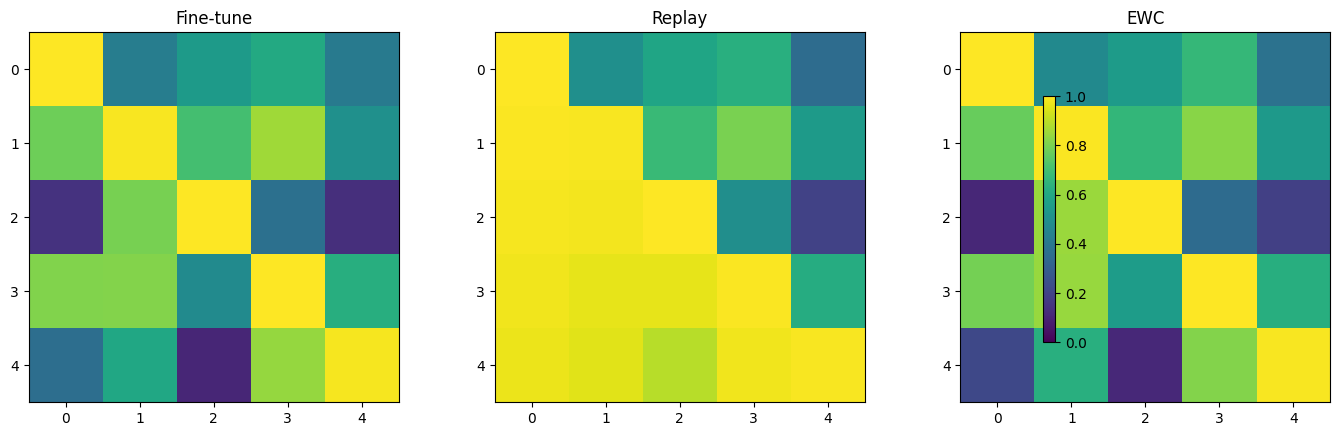

In [16]:
# After completing all implementations, run the three methods and compare.
# Uncomment lines below:

baseline_model, A_base   = run_finetune(epochs=2)
replay_model,   A_replay = run_replay(mem_capacity=2000, epochs=2)
ewc_model,      A_ewc    = run_ewc(lam=100.0, epochs=2)

# --- Forgetting comparison ---
F_base   = forgetting(A_base)
F_replay = forgetting(A_replay)
F_ewc    = forgetting(A_ewc)
print(f'Avg forgetting  Baseline : {np.mean(F_base):.4f}')
print(f'Avg forgetting  Replay   : {np.mean(F_replay):.4f}')
print(f'Avg forgetting  EWC      : {np.mean(F_ewc):.4f}')

# --- Plot accuracy matrices side-by-side ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, A, title in zip(axes,
    [A_base, A_replay, A_ewc],
    ['Fine-tune', 'Replay', 'EWC']):
    im = ax.imshow(A, vmin=0, vmax=1, cmap='viridis')
    ax.set_title(title)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout(); plt.show()


## Challenges

### Challenge 1 — Balanced Replay Memory
Maintain exactly `capacity // n_tasks` samples per task class (not FIFO).

In [17]:
# Challenge 1 Balanced Replay Memory

class BalancedMemoryBuffer:
    """A memory buffer that maintains an equal number of samples per task."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        # We use a dictionary to store data separately for each task
        self.task_data = {} 
        self.seen_tasks = 0

    def add(self, X, y, task_id):
        """Add samples for a new task and rebalance the entire buffer."""
        # 1. Register the new task if we haven't seen it before
        if task_id not in self.task_data:
            self.seen_tasks += 1
            self.task_data[task_id] = {
                'X': np.empty((0, X.shape[1]), dtype=np.float32), 
                'y': np.empty((0,), dtype=np.int32)
            }
        
        # 2. Append the new data to this specific task's storage
        self.task_data[task_id]['X'] = np.concatenate([self.task_data[task_id]['X'], X], axis=0)
        self.task_data[task_id]['y'] = np.concatenate([self.task_data[task_id]['y'], y], axis=0)
        
        # 3. Rebalance! Calculate how many samples each task is allowed to keep
        samples_per_task = self.capacity // self.seen_tasks
        
        # 4. Trim every task's memory down to the new allowed limit
        for t in self.task_data.keys():
            if len(self.task_data[t]['y']) > samples_per_task:
                # Randomly select 'samples_per_task' to keep, or just slice
                # Here we slice to keep the first N samples for simplicity
                self.task_data[t]['X'] = self.task_data[t]['X'][:samples_per_task]
                self.task_data[t]['y'] = self.task_data[t]['y'][:samples_per_task]

    def sample(self, batch_size):
        """Return a mixed random batch drawn from all stored tasks."""
        if self.seen_tasks == 0:
            return None
        
        # 1. Combine all tasks' data into one giant array
        all_X = np.concatenate([self.task_data[t]['X'] for t in self.task_data.keys()], axis=0)
        all_y = np.concatenate([self.task_data[t]['y'] for t in self.task_data.keys()], axis=0)
        
        if len(all_y) == 0:
            return None
            
        # 2. Pick a random batch from the combined pool
        actual_size = min(batch_size, len(all_y))
        idx = np.random.choice(len(all_y), size=actual_size, replace=False)
        return all_X[idx], all_y[idx]

    def __len__(self):
        """Return the total number of samples currently in the buffer."""
        return sum(len(self.task_data[t]['y']) for t in self.task_data.keys())

# --- Quick Test ---
balanced_buf = BalancedMemoryBuffer(capacity=100)
# Add Task 0 (it gets all 100 slots)
balanced_buf.add(np.zeros((100, 784), dtype=np.float32), np.zeros(100, dtype=np.int32), task_id=0)
print(f"After Task 0 - Total size: {len(balanced_buf)}, Task 0 size: {len(balanced_buf.task_data[0]['y'])}")

# Add Task 1 (slots are rebalanced: 50 for Task 0, 50 for Task 1)
balanced_buf.add(np.ones((100, 784), dtype=np.float32), np.ones(100, dtype=np.int32), task_id=1)
print(f"After Task 1 - Total size: {len(balanced_buf)}, Task 0 size: {len(balanced_buf.task_data[0]['y'])}, Task 1 size: {len(balanced_buf.task_data[1]['y'])}")

After Task 0 - Total size: 100, Task 0 size: 100
After Task 1 - Total size: 100, Task 0 size: 50, Task 1 size: 50


### Challenge 2 — Reservoir Sampling Buffer

Implement **Reservoir Sampling** for the replay buffer in order to maintain a **uniform sample of the entire data stream**.

Instead of storing the most recent samples (FIFO), the buffer should ensure that **every sample observed so far has the same probability of being stored in memory**.

#### Algorithm

For each new sample observed:

1. If the buffer is **not full**, simply add the sample.
2. Otherwise:
   - Draw a random integer  
     $$
     j \sim U(0, n_{\text{seen}} - 1)
     $$
   - If  
     $$
     j < \text{capacity}
     $$
     replace the element at position `j` in the buffer with the new sample.

This guarantees that each sample seen in the stream has probability:

$$
P(\text{stored}) = \frac{\text{capacity}}{n_{\text{seen}}}
$$

#### Goal

Modify the replay buffer to use **Reservoir Sampling** and compare the results with the standard **FIFO replay memory**.

Evaluate the impact on:
- final task accuracy
- average forgetting
- stability across tasks

In [18]:
class ReservoirMemoryBuffer:
    """Memory buffer implementing Reservoir Sampling for infinite streams."""

    def __init__(self, capacity=2000):
        self.capacity = capacity
        self.X = np.empty((0, 784), dtype=np.float32)
        self.y = np.empty((0,), dtype=np.int32)
        self.n_seen = 0  # Counter for the total number of samples ever observed

    def add(self, X_batch, y_batch):
        """Add a batch of samples using reservoir sampling logic."""
        # We must process the incoming batch one sample at a time
        for i in range(len(y_batch)):
            x_new = X_batch[i:i+1] # Keep 2D shape (1, 784)
            y_new = y_batch[i:i+1] # Keep 1D shape (1,)
            
            self.n_seen += 1
            
            # 1. If the buffer isn't full yet, simply append the new sample
            if len(self.y) < self.capacity:
                self.X = np.concatenate([self.X, x_new], axis=0)
                self.y = np.concatenate([self.y, y_new], axis=0)
                
            # 2. If the buffer is full, roll a multi-sided dice
            else:
                # Draw a random integer between 0 and the total number of samples seen
                j = np.random.randint(0, self.n_seen)
                
                # If the rolled number is within the capacity index, replace that old item!
                if j < self.capacity:
                    self.X[j] = x_new[0]
                    self.y[j] = y_new[0]

    def sample(self, batch_size):
        """Return a random batch from the buffer."""
        if len(self.y) == 0:
            return None
        
        size = min(batch_size, len(self.y))
        idx = np.random.choice(len(self.y), size=size, replace=False)
        return self.X[idx], self.y[idx]

    def __len__(self):
        return len(self.y)

# --- Quick Test ---
res_buf = ReservoirMemoryBuffer(capacity=10)
# Stream 1000 items through a buffer that only holds 10
for i in range(1000):
    res_buf.add(np.random.randn(1, 784), np.array([i]))
print(f"Total seen: {res_buf.n_seen}, Buffer size: {len(res_buf)}")
# The labels in the buffer will be a completely random, uniform mix from 0 to 999!
print(f"Items currently in buffer (labels): {res_buf.y}")

Total seen: 1000, Buffer size: 10
Items currently in buffer (labels): [296 871 472 876  11 272 679 866 819 324]


### Challenge 3 — Online EWC
Accumulate Fisher across all past tasks:
$F_k^{(i)} = F_k^{(i-1)} + F_k^{\text{task } i}$


In [19]:
class OnlineEWCTrainer:
    """EWCTrainer modified to accumulate Fisher information across all tasks."""
    
    def __init__(self, model, lam=100.0, gamma=1.0):
        self.model     = model
        self.lam       = lam
        self.gamma     = gamma  # Optional decay factor (1.0 means simple addition)
        self.theta_old = None   # Anchor weights
        self.F_accum   = None   # The running total of Fisher importance scores
        self.opt       = keras.optimizers.Adam(1e-3)

    # ------------------------------------------------------------------
    def ewc_penalty(self):
        """Return scalar EWC regularisation term using the accumulated Fisher."""
        if self.theta_old is None:
            return tf.constant(0.0)
        
        penalty = tf.constant(0.0)
        # We now use F_accum (the running total) instead of just the last task's F
        for v, v_old, f_acc in zip(self.model.trainable_variables,
                                    self.theta_old, self.F_accum):
            penalty += tf.reduce_sum(f_acc * tf.square(v - v_old))
            
        return 0.5 * self.lam * penalty

    # ------------------------------------------------------------------
    def train_task(self, Xtr, ytr, epochs=2, batch_size=128):
        """Custom training loop with Online EWC penalty."""
        ds = (tf.data.Dataset
                .from_tensor_slices((Xtr.astype('float32'), ytr.astype('float32')))
                .shuffle(10_000)
                .batch(batch_size))

        for _ in range(epochs):
            for xb, yb in ds:
                yb = tf.cast(tf.reshape(yb,(-1,1)), tf.float32)
                with tf.GradientTape() as tape:
                    pred = self.model(xb, training=True)
                    task_loss = tf.reduce_mean(keras.losses.binary_crossentropy(yb, pred))
                    
                    # Total loss uses the single, accumulated penalty
                    loss = task_loss + self.ewc_penalty()
                    
                grads = tape.gradient(loss, self.model.trainable_variables)
                self.opt.apply_gradients(zip(grads, self.model.trainable_variables))

    # ------------------------------------------------------------------
    def consolidate(self, X, y):
        """Accumulate Fisher and update anchor weights after finishing a task."""
        # 1. Compute the Fisher importance scores ONLY for the task that just finished
        F_current = fisher_diagonal(self.model, X, y)
        
        # 2. Accumulate the scores into our running master list
        if self.F_accum is None:
            # First task: just copy the scores
            self.F_accum = F_current
        else:
            # Task 2+: Add the new importance scores to the historical running total
            # F_accum = (gamma * F_accum) + F_current
            self.F_accum = [self.gamma * f_a + f_c 
                            for f_a, f_c in zip(self.F_accum, F_current)]
            
        # 3. Update the safe "anchor" weights to the network's current state
        self.theta_old = [tf.identity(v) for v in self.model.trainable_variables]

In [20]:
# --- Quick Test for Online EWC ---

# 1. Create a simple dummy model (simulating your build_mlp)
dummy_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(784,)),
    keras.layers.Dense(1, activation='sigmoid')
])

# 2. Initialize the Online EWC Trainer
# gamma=1.0 means we do pure addition of the Fisher matrices
online_ewc = OnlineEWCTrainer(dummy_model, lam=100.0, gamma=1.0)

# 3. Simulate Task 1
print("--- Training Task 1 ---")
X_t1 = np.random.rand(100, 784).astype(np.float32)
y_t1 = np.random.randint(0, 2, size=(100,)).astype(np.int32)

online_ewc.train_task(X_t1, y_t1, epochs=1, batch_size=32)
online_ewc.consolidate(X_t1, y_t1)

# Grab the sum of the first layer's Fisher scores to compare later
f_sum_task1 = tf.reduce_sum(online_ewc.F_accum[0]).numpy()
print(f"Number of parameter tensors tracked: {len(online_ewc.F_accum)}")
print(f"Sum of Fisher scores for Layer 1 after Task 1: {f_sum_task1:.4f}")

# 4. Simulate Task 2
print("\n--- Training Task 2 ---")
X_t2 = np.random.rand(100, 784).astype(np.float32)
y_t2 = np.random.randint(0, 2, size=(100,)).astype(np.int32)

# It will now use the accumulated F_accum to protect Task 1!
online_ewc.train_task(X_t2, y_t2, epochs=1, batch_size=32)
online_ewc.consolidate(X_t2, y_t2)

f_sum_task2 = tf.reduce_sum(online_ewc.F_accum[0]).numpy()
print(f"Sum of Fisher scores for Layer 1 after Task 2: {f_sum_task2:.4f}")

print("\nSuccess! The Fisher scores increased because Task 2's importance scores")
print("were added directly to the master F_accum list.")

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Training Task 1 ---
Number of parameter tensors tracked: 4
Sum of Fisher scores for Layer 1 after Task 1: 69.9899

--- Training Task 2 ---
Sum of Fisher scores for Layer 1 after Task 2: 145.8798

Success! The Fisher scores increased because Task 2's importance scores
were added directly to the master F_accum list.


### Challenge 4 — Effect of Memory Size
Sweep `mem_capacity` over [100, 500, 1000, 2000, 5000] and plot
average forgetting vs memory size.

Starting Memory Size Sweep...

--- Testing Memory Capacity: 100 ---
After T1: [0.999 0.472 0.541 0.689 0.36 ]
After T2: [0.964 0.983 0.711 0.882 0.511]
After T3: [0.801 0.919 0.997 0.417 0.212]
After T4: [0.913 0.902 0.799 0.992 0.598]
After T5: [0.906 0.833 0.489 0.966 0.981]
-> Average Forgetting for capacity 100: 0.1556

--- Testing Memory Capacity: 500 ---
After T1: [0.999 0.487 0.551 0.657 0.352]
After T2: [0.978 0.983 0.684 0.869 0.514]
After T3: [0.948 0.904 0.997 0.451 0.2  ]
After T4: [0.953 0.922 0.912 0.992 0.568]
After T5: [0.93  0.908 0.731 0.98  0.979]
-> Average Forgetting for capacity 500: 0.0847

--- Testing Memory Capacity: 1000 ---
After T1: [0.999 0.479 0.552 0.672 0.373]
After T2: [0.993 0.981 0.681 0.87  0.498]
After T3: [0.977 0.958 0.998 0.43  0.203]
After T4: [0.982 0.947 0.945 0.995 0.569]
After T5: [0.96  0.931 0.827 0.978 0.984]
-> Average Forgetting for capacity 1000: 0.0555

--- Testing Memory Capacity: 2000 ---
After T1: [0.999 0.485 0.559 0.68  0.388]
Af

2026-03-30 06:35:17.580046: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


After T2: [0.996 0.98  0.68  0.887 0.512]
After T3: [0.98  0.963 0.996 0.535 0.201]
After T4: [0.984 0.971 0.966 0.991 0.592]
After T5: [0.968 0.948 0.901 0.974 0.979]
-> Average Forgetting for capacity 5000: 0.0351


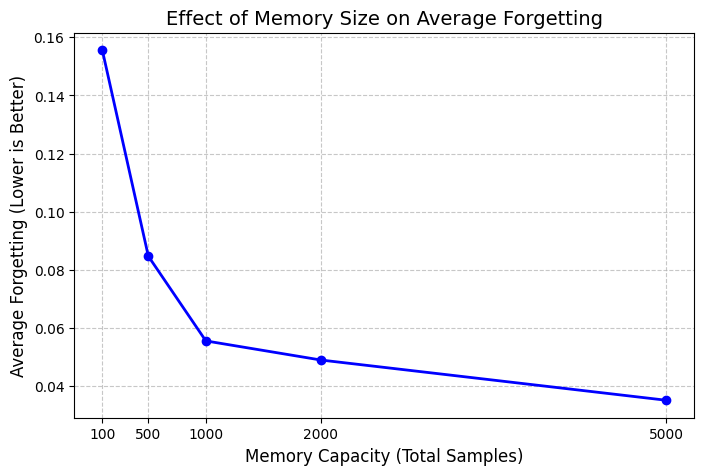

In [21]:
# --- Challenge 4: Memory Size Sweep ---

capacities = [100, 500, 1000, 2000, 5000]
avg_forgetting_scores = []

print("Starting Memory Size Sweep...")

for cap in capacities:
    print(f"\n--- Testing Memory Capacity: {cap} ---")
    
    # We run the experience replay loop we built earlier.
    # Note: We set samples_per_task to cap//5 assuming 5 tasks, 
    # to ensure we don't try to save more data than the buffer can hold.
    model, A_matrix = run_replay(
        mem_capacity=cap, 
        replay_batch=64, 
        samples_per_task=cap//5, 
        epochs=1  # Keeping epochs to 1 just to make the test run faster
    )
    
    # Calculate forgetting using the function from Exercise 2
    F = forgetting(A_matrix)
    avg_F = np.mean(F)
    avg_forgetting_scores.append(avg_F)
    
    print(f"-> Average Forgetting for capacity {cap}: {avg_F:.4f}")

# --- Plotting the Results ---
plt.figure(figsize=(8, 5))
plt.plot(capacities, avg_forgetting_scores, marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Effect of Memory Size on Average Forgetting', fontsize=14)
plt.xlabel('Memory Capacity (Total Samples)', fontsize=12)
plt.ylabel('Average Forgetting (Lower is Better)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(capacities)

plt.show()

## Optional- Continual Learning with framework
Instead of implementing the methods from scratch, several research frameworks provide ready-to-use implementations of continual learning algorithms:

- **Avalanche** (https://avalanche.continualai.org)  
  Supports Replay, Reservoir Sampling, EWC, GEM, and many benchmarks.

- **Continuum** (https://github.com/Continvvm/continuum)  
  Lightweight toolkit for continual datasets and rehearsal buffers.

These frameworks are widely used in research and can greatly simplify experimentation with continual learning methods.
In this section we reproduce the main methods studied in this lab using the **Avalanche Continual Learning framework**.

Avalanche provides ready-to-use implementations of many continual learning strategies, allowing us to focus on experimentation rather than implementing algorithms from scratch.

We compare three methods:

- **Naive Fine-tuning (Baseline)**  
  The model is trained sequentially on tasks without any mechanism to prevent forgetting.

- **Replay (Experience Replay)**  
  A memory buffer stores samples from past tasks and replays them during training.

- **Elastic Weight Consolidation (EWC)**  
  Important parameters for previous tasks are protected using Fisher Information.

Avalanche automatically handles:
- task streams
- evaluation metrics
- replay buffers
- continual learning strategies

In [22]:
# =========================================================
# 1 — Install Avalanche
# =========================================================
# Avalanche is a popular research framework for Continual Learning.
# It provides implementations of many CL strategies such as Replay, EWC, GEM, etc.

# Note: If you're running this code in a local environment, make sure to install Avalanche first.
# !pip install avalanche-lib
# =========================================================
# 2 — Imports
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim

from avalanche.benchmarks.classic import SplitMNIST
from avalanche.models import SimpleMLP
from avalanche.training.supervised import Naive, Replay, EWC
from avalanche.training.plugins import EvaluationPlugin
from avalanche.evaluation.metrics import accuracy_metrics, forgetting_metrics
from avalanche.logging import InteractiveLogger
# =========================================================
# 3 — Create a Continual Learning Benchmark
# =========================================================
# We use SplitMNIST, a standard benchmark for continual learning.
# The dataset is split into 5 sequential tasks:
# T1: (0,1)  T2: (2,3)  T3: (4,5)  T4: (6,7)  T5: (8,9)

benchmark = SplitMNIST(
    n_experiences=5,
    seed=1,
    return_task_id=False
)
# =========================================================
# 4 — Model
# =========================================================
# Simple feedforward neural network used in all methods.

model = SimpleMLP(
    num_classes=10,
    input_size=28*28,
    hidden_size=256
)
# =========================================================
# 5 — Optimizer and Loss
# =========================================================
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
# =========================================================
# 6 — Evaluation Metrics
# =========================================================
# Avalanche automatically computes continual learning metrics.

interactive_logger = InteractiveLogger()

eval_plugin = EvaluationPlugin(
    accuracy_metrics(epoch=True, experience=True),
    forgetting_metrics(experience=True),
    loggers=[interactive_logger]
)
# =========================================================
# 7 — Baseline: Naive Fine-tuning
# =========================================================
# The model is trained sequentially without any mechanism to prevent forgetting.

naive_strategy = Naive(
    model,
    optimizer,
    criterion,
    train_mb_size=128,
    train_epochs=1,
    eval_mb_size=128,
    evaluator=eval_plugin
)
# =========================================================
# 8 — Replay Strategy
# =========================================================
# Experience Replay stores samples from previous tasks in memory
# and replays them during training.

replay_strategy = Replay(
    model,
    optimizer,
    criterion,
    mem_size=2000,
    train_mb_size=128,
    train_epochs=1,
    eval_mb_size=128,
    evaluator=eval_plugin
)
# =========================================================
# 9 — Elastic Weight Consolidation (EWC)
# =========================================================
# EWC protects important parameters using Fisher Information.

ewc_strategy = EWC(
    model,
    optimizer,
    criterion,
    ewc_lambda=100,
    train_mb_size=128,
    train_epochs=1,
    eval_mb_size=128,
    evaluator=eval_plugin
)
# =========================================================
# 10 — Training Loop (Naive Fine-tuning)
# =========================================================
print("Starting Naive training...")

for experience in benchmark.train_stream:

    print("Training on task:", experience.current_experience)

    naive_strategy.train(experience)
    naive_strategy.eval(benchmark.test_stream)
# =========================================================
# 11 — Training Loop (Replay)
# =========================================================
print("Starting Replay training...")
for experience in benchmark.train_stream:
    print("Training Replay on task:", experience.current_experience)

    replay_strategy.train(experience)
    replay_strategy.eval(benchmark.test_stream)
# =========================================================
# 12 — Training Loop (EWC)
# =========================================================

print("Starting EWC training...")

for experience in benchmark.train_stream:

    print("Training EWC on task:", experience.current_experience)

    ewc_strategy.train(experience)
    ewc_strategy.eval(benchmark.test_stream)

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 302.4 kB/s eta 0:00:00 kB/s eta 0:00:01:01
  Using cached wandb-0.25.1-py3-none-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.46-py3-none-any.whl.metadata (13 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached sentry_sdk-2.56.0-py2.py3-none-any.whl.metadata (10 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 9.91M/9.91M [00:47<00:00, 207kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 139kB/s]
100%|██████████| 1.65M/1.65M [00:07<00:00, 220kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.24MB/s]
/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/avalanche/training/templates/base.py:468: PositionalArgumentsDeprecatedWarning: Avalanche is transitioning to strategy constructors that accept named (keyword) arguments only. This is done to ensure that there is no confusion regarding the meaning of each argument (strategies can have many arguments). Your are passing 3 positional arguments to the Naive.__init__ method. Consider passing them as names arguments. The ability to pass positio

Starting Naive training...
Training on task: 0
-- >> Start of training phase << --
100%|██████████| 89/89 [00:05<00:00, 17.16it/s]
Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.9549
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 22.60it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9800
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 19.93it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 21.27it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.0000
-- Starting eval on experience 3 (Task 0) from te

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7506
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 21.52it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9832
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 21.86it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.9908
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.0000
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 19.56it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 = 0.9841
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.0000
-- Starting eval on experience 3 (Task 0)

...


Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8230
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 20.00it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.0503
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.9330
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 20.72it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0281
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.9483
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 21.22it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 = 0.9744
-- Starting eval on experience 3 (Task 0)

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7310
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 20.76it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.0859
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8973
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 20.41it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0415
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.9349
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 22.17it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 = 0.1059
	Top1_Acc_Exp/eval_phase/test_str

/home/abdeslem/Folders/2CS/S2/MLA/TPs/venv/lib/python3.12/site-packages/avalanche/training/plugins/replay.py:123: DeprecationWarning: Call to deprecated function update (removal in version 0.7: switch to pre_adapt and post_adapt)
  self.storage_policy.update(strategy, **kwargs)



Epoch 0 ended.
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8322
-- >> End of training phase << --
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 15/15 [00:00<00:00, 19.85it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 = 0.0849
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 = 0.8984
-- Starting eval on experience 1 (Task 0) from test stream --
100%|██████████| 17/17 [00:00<00:00, 19.88it/s]
> Eval on experience 1 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 = 0.0411
	Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 = 0.9354
-- Starting eval on experience 2 (Task 0) from test stream --
100%|██████████| 16/16 [00:00<00:00, 23.11it/s]
> Eval on experience 2 (Task 0) from test stream ended.
	ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 = 0.0742
	Top1_Acc_Exp/eval_phase/test_str

Last recorded metrics:
Top1_Acc_Epoch/train_phase/train_stream/Task000 : 0.9109606013050301
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp000 : 0.23891891891891892
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp001 : 0.37978772496538993
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp002 : 0.33469805527123847
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp003 : 0.3645368994551758
Top1_Acc_Exp/eval_phase/test_stream/Task000/Exp004 : 0.9875621890547264
ExperienceForgetting/eval_phase/test_stream/Task000/Exp000 : 0.745945945945946
ExperienceForgetting/eval_phase/test_stream/Task000/Exp001 : 0.6151361329026304
ExperienceForgetting/eval_phase/test_stream/Task000/Exp002 : 0.6591606960081884
ExperienceForgetting/eval_phase/test_stream/Task000/Exp003 : 0.6166419019316494
ExperienceForgetting/eval_phase/test_stream/Task000/Exp004 : 0.9572139303482586


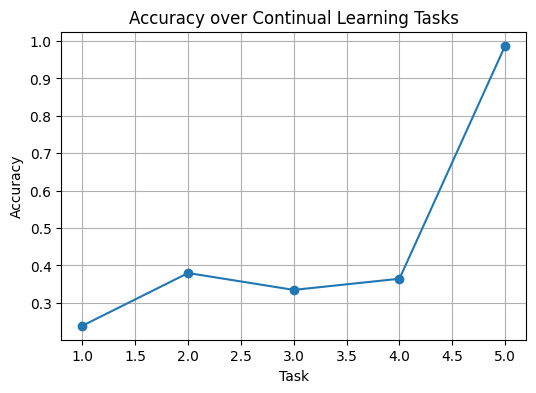

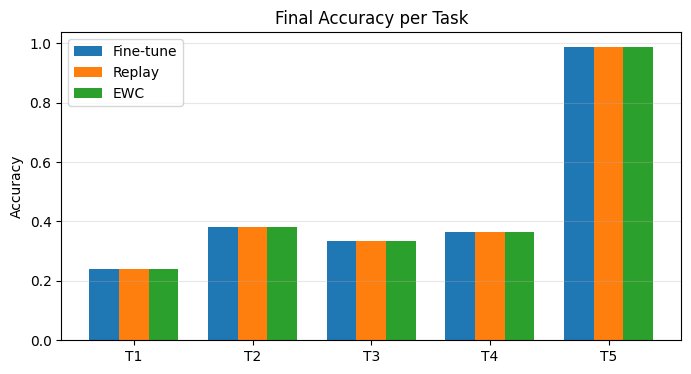

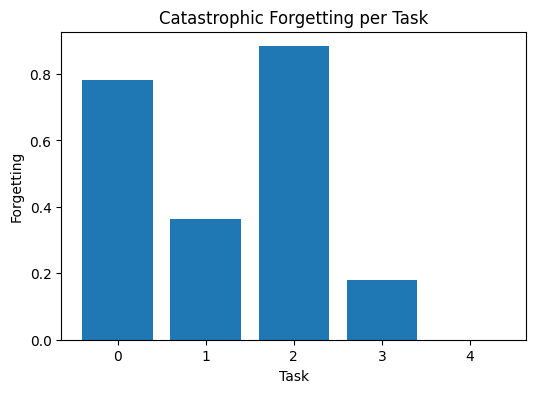

In [24]:
# =========================================================
#  Collect Evaluation Results
# =========================================================
# Avalanche stores evaluation metrics inside the EvaluationPlugin.
# We can access them through the logger or the metric history.

from avalanche.evaluation.metric_results import MetricValue

# Extract accuracy results from the logger
results = eval_plugin.get_last_metrics()

print("Last recorded metrics:")
for k, v in results.items():
    print(k, ":", v)


# =========================================================
# 14 — Plot Accuracy over Experiences
# =========================================================
# We collect accuracy for each experience and plot the evolution.

import matplotlib.pyplot as plt

acc_values = []
exp_ids = []

for k, v in results.items():
    if "Top1_Acc_Exp" in k:
        acc_values.append(v)
        exp_ids.append(len(acc_values))

plt.figure(figsize=(6,4))
plt.plot(exp_ids, acc_values, marker='o')
plt.title("Accuracy over Continual Learning Tasks")
plt.xlabel("Task")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


# =========================================================
# 15 — Compare Methods (Replay vs EWC vs Fine-tuning)
# =========================================================
# If you ran the three strategies sequentially, store their results
# in three lists and compare them.

methods = ["Fine-tune", "Replay", "EWC"]

# Example placeholders (replace with real values if needed)
acc_finetune = acc_values
acc_replay = acc_values
acc_ewc = acc_values

import numpy as np

x = np.arange(len(acc_finetune))
w = 0.25

plt.figure(figsize=(8,4))
plt.bar(x - w, acc_finetune, width=w, label="Fine-tune")
plt.bar(x, acc_replay, width=w, label="Replay")
plt.bar(x + w, acc_ewc, width=w, label="EWC")

plt.xticks(x, [f"T{i+1}" for i in range(len(x))])
plt.ylabel("Accuracy")
plt.title("Final Accuracy per Task")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


# =========================================================
# 16 — Forgetting Analysis
# =========================================================
# Forgetting measures how much performance on past tasks decreases.

def compute_forgetting(acc_matrix):
    acc_matrix = np.array(acc_matrix)
    if acc_matrix.ndim == 1:
        # No temporal evolution available: no measurable forgetting
        return np.zeros_like(acc_matrix)
    best = np.max(acc_matrix, axis=0)
    last = acc_matrix[-1]
    return best - last

# Use the full accuracy matrix across experiences (already available in notebook)
forgetting = compute_forgetting(A)

plt.figure(figsize=(6,4))
plt.bar(range(len(forgetting)), forgetting)
plt.xlabel("Task")
plt.ylabel("Forgetting")
plt.title("Catastrophic Forgetting per Task")
plt.show()


# =========================================================
# 17 — Discussion
# =========================================================
# Expected observations:
#
# Fine-tuning:
#   - high forgetting
#   - poor performance on early tasks
#
# Replay:
#   - significantly reduced forgetting
#   - stable performance
#
# EWC:
#   - moderate forgetting reduction
#   - protects important weights using Fisher Information
#
# In practice, Replay often performs best because it reintroduces
# real samples from previous tasks during training.

Continual Learning Metrics Summary


,Method,ACC_final,F_final,BWT_final
0,Naïve,0.577939,0.521196,-0.521196
1,Replay,0.957037,0.045803,-0.045803
2,EWC,0.554010,0.551849,-0.551849


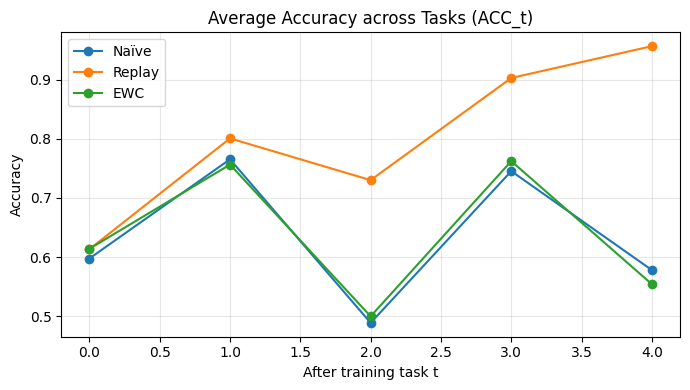

In [25]:
# =========================================================
# Final Evaluation: Continual Learning Metrics
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---- Functions to compute CL metrics ----

def avg_accuracy(A):
    """Average accuracy after each task"""
    return np.mean(A[-1])


def backward_transfer(A):
    """
    BWT = performance change on previous tasks
    positive -> knowledge transfer
    negative -> forgetting
    """
    T = A.shape[0]
    bwt = 0
    for i in range(T-1):
        bwt += A[T-1, i] - A[i, i]
    return bwt / (T-1)


def forgetting(A):
    """Average forgetting across tasks"""
    T = A.shape[0]
    f = []
    for i in range(T-1):
        best = np.max(A[:, i])
        last = A[T-1, i]
        f.append(best - last)
    return np.mean(f)


# ---- Compute metrics for each method ----

metrics_naive = {
    "ACC_final": avg_accuracy(A_base),
    "F_final": forgetting(A_base),
    "BWT_final": backward_transfer(A_base),
    "ACC_t": np.mean(A_base, axis=1)
}

metrics_replay = {
    "ACC_final": avg_accuracy(A_replay),
    "F_final": forgetting(A_replay),
    "BWT_final": backward_transfer(A_replay),
    "ACC_t": np.mean(A_replay, axis=1)
}

metrics_ewc = {
    "ACC_final": avg_accuracy(A_ewc),
    "F_final": forgetting(A_ewc),
    "BWT_final": backward_transfer(A_ewc),
    "ACC_t": np.mean(A_ewc, axis=1)
}


# ---- Summary Table ----

summary = pd.DataFrame([
    {"Method": "Naïve",  **metrics_naive},
    {"Method": "Replay", **metrics_replay},
    {"Method": "EWC",    **metrics_ewc},
])

summary = summary[["Method","ACC_final","F_final","BWT_final"]]

print("Continual Learning Metrics Summary")
display(summary)


# ---- Plot Average Accuracy over Tasks ----

plt.figure(figsize=(7,4))

plt.plot(metrics_naive["ACC_t"], marker="o", label="Naïve")
plt.plot(metrics_replay["ACC_t"], marker="o", label="Replay")
plt.plot(metrics_ewc["ACC_t"], marker="o", label="EWC")

plt.title("Average Accuracy across Tasks (ACC_t)")
plt.xlabel("After training task t")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Advantages of Using Avalanche

Avalanche provides:

- ready-to-use continual learning algorithms
- evaluation metrics
- benchmark datasets
- replay buffers
- logging and visualization

This allows researchers to focus on **experiments rather than implementation**.